# Ejemplo Sencillo de Método de Elementos Finitos en 2D

Este notebook presenta una implementación simple del método de elementos finitos para resolver la ecuación de Poisson en 2D en un dominio cuadrado unitario.

El notebook incluye una malla simple 3x3 con elementos triangulares, que es suficiente para demostrar los conceptos básicos sin complicar demasiado el código. 

see: https://users.metu.edu.tr/csert/me582/ME582%20Ch%2003.pdf

## 1. Importación de Librerías

Importamos las librerías necesarias para cálculos numéricos, matrices sparse y visualización.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

# Configuración de matplotlib
plt.style.use('default')
plt.rcParams['figure.figsize'] = (8, 6)

## 2. Definición del Problema

Resolveremos la ecuación de Poisson: $-\nabla^2 u(x,y) = f(x,y)$ en el dominio $[0,1] × [0,1]$ con condiciones de frontera de Dirichlet $u = 0$ en el borde.

Usaremos $f = 1$ para un ejemplo simple.

## 3. Generación de la Malla

Creamos una malla triangular simple dividiendo el cuadrado en dos triángulos.

Número de nodos: 9
Número de elementos: 8


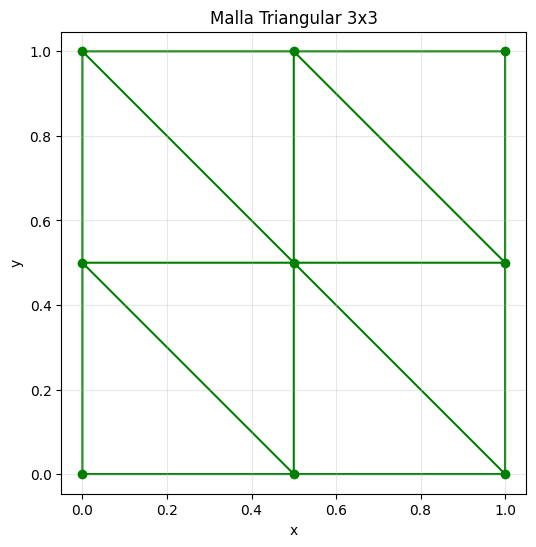

In [3]:
# Nodos de la malla (9 nodos en una cuadrícula 3x3)
x_coords = np.linspace(0, 1, 3)
y_coords = np.linspace(0, 1, 3)
X, Y = np.meshgrid(x_coords, y_coords)
nodes = np.column_stack((X.ravel(), Y.ravel()))

# Elementos (8 triángulos dividiendo cada cuadrado en 2)
elements = np.array([
    [0, 1, 3], [1, 4, 3],  # inferior izquierdo
    [1, 2, 4], [2, 5, 4],  # inferior derecho
    [3, 4, 6], [4, 7, 6],  # superior izquierdo
    [4, 5, 7], [5, 8, 7]   # superior derecho
])

# Número de nodos y elementos
n_nodes = len(nodes)
n_elements = len(elements)

print(f"Número de nodos: {n_nodes}")
print(f"Número de elementos: {n_elements}")

# Visualización de la malla
plt.figure(figsize=(6, 6))
plt.triplot(nodes[:, 0], nodes[:, 1], elements, 'go-')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Malla Triangular 3x3')
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.show()

## 4. Funciones Base

Usaremos elementos triangulares lineales con funciones base:
- $φ₁(ξ,η) = 1 - ξ - η$
- $φ₂(ξ,η) = ξ$
- $φ₃(ξ,η) = η$

donde $(ξ,η)$ son coordenadas locales en el triángulo de referencia.

## 5. Ensamblaje de la Matriz de Rigidez

La matriz de rigidez elemental para un triángulo lineal es:
$$K_e = \frac{1}{2A} \begin{pmatrix} b_1^2 + c_1^2 & b_1 b_2 + c_1 c_2 & b_1 b_3 + c_1 c_3 \\ b_2 b_1 + c_2 c_1 & b_2^2 + c_2^2 & b_2 b_3 + c_2 c_3 \\ b_3 b_1 + c_3 c_1 & b_3 b_2 + c_3 c_2 & b_3^2 + c_3^2 \end{pmatrix}$$

donde $b_i, c_i$ son derivadas de las funciones de forma.

In [4]:
# Función para calcular el área de un triángulo
def triangle_area(nodes_elem):
    x1, y1 = nodes_elem[0]
    x2, y2 = nodes_elem[1]
    x3, y3 = nodes_elem[2]
    return 0.5 * abs((x2 - x1)*(y3 - y1) - (x3 - x1)*(y2 - y1))

# Función para calcular la matriz de rigidez elemental
def element_stiffness(nodes_elem):
    x1, y1 = nodes_elem[0]
    x2, y2 = nodes_elem[1]
    x3, y3 = nodes_elem[2]

    # Área
    A = triangle_area(nodes_elem)

    # Coeficientes b y c
    b1 = y2 - y3
    b2 = y3 - y1
    b3 = y1 - y2
    c1 = x3 - x2
    c2 = x1 - x3
    c3 = x2 - x1

    # Matriz de rigidez elemental
    Ke = np.array([
        [b1*b1 + c1*c1, b1*b2 + c1*c2, b1*b3 + c1*c3],
        [b2*b1 + c2*c1, b2*b2 + c2*c2, b2*b3 + c2*c3],
        [b3*b1 + c3*c1, b3*b2 + c3*c2, b3*b3 + c3*c3]
    ]) / (4 * A)

    return Ke

# Matriz de rigidez global
K = lil_matrix((n_nodes, n_nodes))

# Ensamblaje
for elem in elements:
    nodes_elem = nodes[elem]
    Ke = element_stiffness(nodes_elem)
    for i in range(3):
        for j in range(3):
            K[elem[i], elem[j]] += Ke[i, j]

print("Matriz de rigidez global:")
print(K.toarray())

Matriz de rigidez global:
[[ 1.  -0.5  0.  -0.5  0.   0.   0.   0.   0. ]
 [-0.5  2.  -0.5  0.  -1.   0.   0.   0.   0. ]
 [ 0.  -0.5  1.   0.   0.  -0.5  0.   0.   0. ]
 [-0.5  0.   0.   2.  -1.   0.  -0.5  0.   0. ]
 [ 0.  -1.   0.  -1.   4.  -1.   0.  -1.   0. ]
 [ 0.   0.  -0.5  0.  -1.   2.   0.   0.  -0.5]
 [ 0.   0.   0.  -0.5  0.   0.   1.  -0.5  0. ]
 [ 0.   0.   0.   0.  -1.   0.  -0.5  2.  -0.5]
 [ 0.   0.   0.   0.   0.  -0.5  0.  -0.5  1. ]]


## 6. Ensamblaje del Vector de Carga

Para $f = 1$, el vector de carga elemental es:
$$F_e = \frac{A}{3} \begin{pmatrix} 1 \\ 1 \\ 1 \end{pmatrix}$$

donde $A$ es el área del elemento.

In [5]:
# Vector de carga global
F = np.zeros(n_nodes)

# Ensamblaje del vector de carga
for elem in elements:
    nodes_elem = nodes[elem]
    A = triangle_area(nodes_elem)
    Fe = (A/3)*np.ones(3)  # f = 1
    for i in range(3):
        F[elem[i]] += Fe[i]

print("Vector de carga global:")
print(F)

Vector de carga global:
[0.04166667 0.125      0.08333333 0.125      0.25       0.125
 0.08333333 0.125      0.04166667]


## 7. Aplicación de Condiciones de Frontera

Aplicamos condiciones de Dirichlet $u = 0$ en todos los nodos del borde (todos los nodos en este caso).

In [6]:
# Nodos del borde
boundary_nodes = []
for i, (x, y) in enumerate(nodes):
    if x == 0 or x == 1 or y == 0 or y == 1:
        boundary_nodes.append(i)

print(f"Nodos del borde: {boundary_nodes}")

# Aplicar condiciones de frontera Dirichlet u=0 en nodos del borde
for i in boundary_nodes:
    K[i, :] = 0
    K[i, i] = 1
    F[i] = 0

print("Sistema después de aplicar BC:")
print("K:")
print(K.toarray())
print("F:")
print(F)

Nodos del borde: [0, 1, 2, 3, 5, 6, 7, 8]
Sistema después de aplicar BC:
K:
[[ 1.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  1.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  1.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  1.  0.  0.  0.  0.  0.]
 [ 0. -1.  0. -1.  4. -1.  0. -1.  0.]
 [ 0.  0.  0.  0.  0.  1.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  1.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  1.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  1.]]
F:
[0.   0.   0.   0.   0.25 0.   0.   0.   0.  ]


## 8. Resolución del Sistema

Resolvemos el sistema lineal $Ku = F$ para obtener la solución aproximada.

In [7]:
# Resolver el sistema
u = spsolve(K.tocsr(), F)

print("Solución u en cada nodo:")
for i, val in enumerate(u):
    print(f"Nodo {i} ({nodes[i][0]:.1f}, {nodes[i][1]:.1f}): u = {val:.4f}")

Solución u en cada nodo:
Nodo 0 (0.0, 0.0): u = 0.0000
Nodo 1 (0.5, 0.0): u = 0.0000
Nodo 2 (1.0, 0.0): u = 0.0000
Nodo 3 (0.0, 0.5): u = 0.0000
Nodo 4 (0.5, 0.5): u = 0.0625
Nodo 5 (1.0, 0.5): u = 0.0000
Nodo 6 (0.0, 1.0): u = 0.0000
Nodo 7 (0.5, 1.0): u = 0.0000
Nodo 8 (1.0, 1.0): u = 0.0000


In [8]:
u

array([0.    , 0.    , 0.    , 0.    , 0.0625, 0.    , 0.    , 0.    ,
       0.    ])

## 9. Visualización de Resultados

Visualizamos la solución aproximada usando una interpolación triangular.

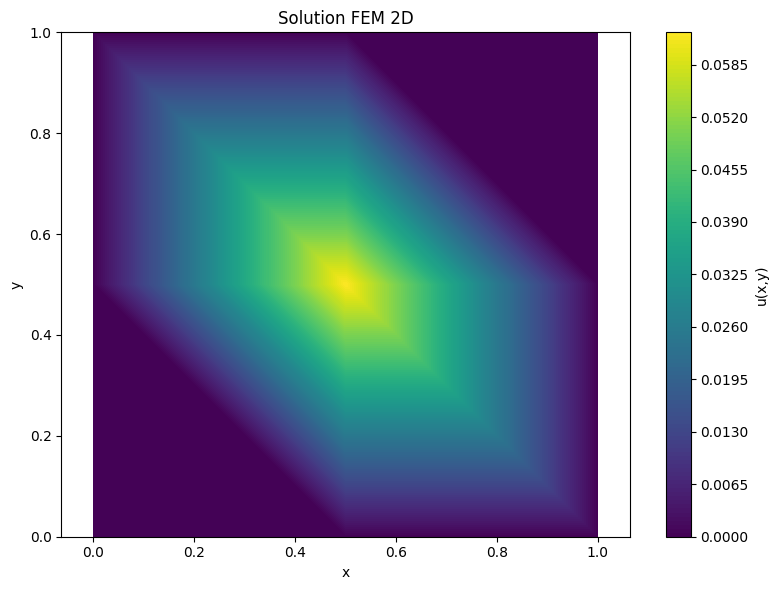

Valor máximo de u: 0.0625
Valor en el centro: 0.0625


In [10]:
# Visualización
plt.figure(figsize=(8, 6))

# Gráfico de contornos
plt.tricontourf(nodes[:, 0], nodes[:, 1], elements, u, levels=150, cmap='viridis')
plt.colorbar(label='u(x,y)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Solution FEM 2D')
plt.axis('equal')

plt.tight_layout()
plt.show()

print(f"Valor máximo de u: {np.max(u):.4f}")
print(f"Valor en el centro: {u[4]:.4f}")  # Nodo central

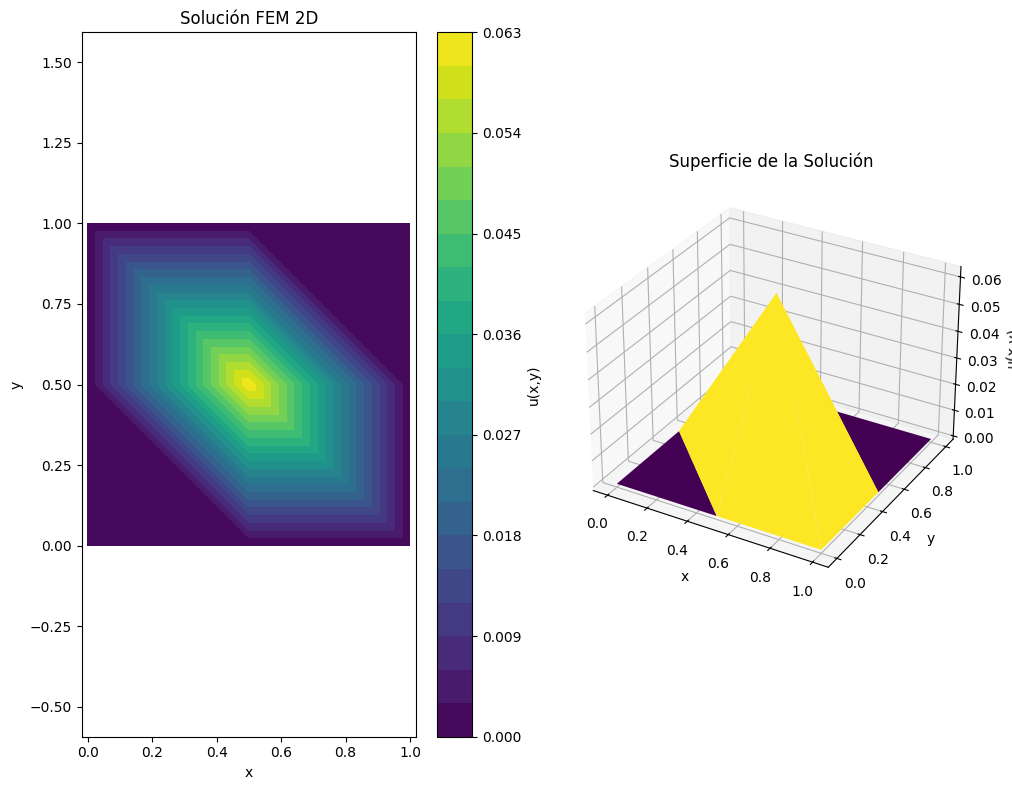

Valor máximo de u: 0.0625
Valor en el centro: 0.0625


In [ ]:
# Visualización
plt.figure(figsize=(10, 8))

# Gráfico de contornos
plt.subplot(1, 2, 1)
plt.tricontourf(nodes[:, 0], nodes[:, 1], elements, u, levels=20, cmap='viridis')
plt.colorbar(label='u(x,y)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Solution FEM 2D')
plt.axis('equal')

# Gráfico 3D
ax = plt.subplot(1, 2, 2, projection='3d')
ax.plot_trisurf(nodes[:, 0], nodes[:, 1], u, triangles=elements, cmap='viridis')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('u(x,y)')
ax.set_title('Superficie de la Solución')

plt.tight_layout()
plt.show()

print(f"Valor máximo de u: {np.max(u):.4f}")
print(f"Valor en el centro: {u[4]:.4f}")  # Nodo central

## Conclusión

Este notebook demostró una implementación básica del método de elementos finitos en 2D usando elementos triangulares lineales. La solución obtenida es una aproximación por partes lineal que satisface las condiciones de frontera.

Para problemas más complejos, se pueden usar:
- Mallados más finos
- Elementos de orden superior
- Librerías especializadas como FEniCS